In [1]:
# Get daily constraint ranked by the abs RT - DA 
import sys
sys.path.append('/var/www/python/Prod/nighthawk/')

import pandas as pd
from nighthawk.data import Constraint

In [2]:
now = pd.Timestamp.now(tz='US/Central')
days_ahead = 2 if now.hour >= 10 else 1
bid_dt = (now + pd.Timedelta(days=days_ahead)).strftime('%Y-%m-%d')
print(bid_dt)

2026-05-23


In [10]:
opex = 'SPP'
end_dt = '2026-05-23'
start_dt = '2026-05-17'


print(f"start_dt: {start_dt}, end_dt: {end_dt}, Market: {opex}")

# Get RT and DA hourly mvalues for all constraints over the date range
print("Fetching RT mvalues...")
mv_rt = Constraint(oops_constraint_num_df=None, market=opex).get_mvalues(
    start_dt=start_dt, end_dt=end_dt, type='RT', granularity='hourly')

print("Fetching DA mvalues...")
mv_da = Constraint(oops_constraint_num_df=None, market=opex).get_mvalues(
    start_dt=start_dt, end_dt=end_dt, type='DA', granularity='hourly')

print(f"RT constraints: {mv_rt['oops_constraint_num'].nunique()}, DA constraints: {mv_da['oops_constraint_num'].nunique()}")

# Sum mvalues per constraint
rt_total = mv_rt.groupby('oops_constraint_num')['mvalue'].sum().rename('rt_total')
da_total = mv_da.groupby('oops_constraint_num')['mvalue'].sum().rename('da_total')

# Merge and compute abs(RT - DA), ranked descending
merged = pd.merge(rt_total, da_total, on='oops_constraint_num', how='outer').fillna(0)
merged['rt_da'] = (merged['rt_total'] - merged['da_total'])
merged = merged.reset_index()

# Get constraint details
all_cons = merged[['oops_constraint_num']].copy()
print("Fetching constraint details...")
details_rt = Constraint(oops_constraint_num_df=all_cons, market=opex).get_constraint_details(da_or_rt='RT')
details_da = Constraint(oops_constraint_num_df=all_cons, market=opex).get_constraint_details(da_or_rt='DA')
details = pd.concat([details_rt, details_da]).drop_duplicates('oops_constraint_num')

# Merge everything
result = pd.merge(merged, details[['oops_constraint_num', 'monitored_clean', 'contingency_clean']], on='oops_constraint_num', how='left')
result = result.rename(columns={'monitored_clean': 'monitored', 'contingency_clean': 'contingency'})
result_final = result.groupby('monitored')[['rt_total','da_total','rt_da']].sum().reset_index()
result_final['abs_rt_da_diff'] = abs(result_final['rt_da'])
# result.drop_duplicates(subset=['monitored'], inplace=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)
display(result_final[[ 'rt_total', 'da_total', 'rt_da', 'abs_rt_da_diff', 'monitored']].sort_values(["rt_total"],ascending=True)[:10])

start_dt: 2026-05-17, end_dt: 2026-05-23, Market: SPP
Fetching RT mvalues...
Fetching DA mvalues...
RT constraints: 108, DA constraints: 154
Fetching constraint details...


,rt_total,da_total,rt_da,abs_rt_da_diff,monitored
100,-22937.0517,-35595.4921,12658.4404,12658.4404,lnpayne_wf-paoli2
163,-22246.6157,0.0000,-22246.6157,22246.6157,xfmrnowst1-nowst1
58,-13608.8296,-7370.2351,-6238.5945,6238.5945,lngracmont-anadarko
24,-13124.4918,-4335.3895,-8789.1023,8789.1023,lnclevlnd7-clev_aec
110,-9708.9002,-10291.3092,582.4090,582.4090,lnrussett-sbrown
11,-8074.7119,-293.3869,-7781.3250,7781.3250,lnbrecknr4-bunck
49,-4824.9625,0.0000,-4824.9625,4824.9625,lnfremont-sub976
30,-4535.1644,-2232.5494,-2302.6150,2302.6150,lncrescent-ctnwd1
134,-3948.5633,-321.8358,-3626.7275,3626.7275,lnwardwa-bismark2
156,-3934.0991,0.0000,-3934.0991,3934.0991,xfmrkell-kell


In [20]:
end_dt2   = pd.Timestamp.now(tz='US/Central').strftime('%Y-%m-%d')
start_dt2 = (pd.Timestamp(end_dt2) - pd.Timedelta(weeks=260)).strftime('%Y-%m-%d')
end_dt2 = '2026-05-23'
start_dt2 = '2025-05-23'


con_df = result_final.merge(result[['oops_constraint_num', 'monitored']], on='monitored', how='left')[['oops_constraint_num']].drop_duplicates()
# Step 1: daily mvalues to find active days
mv_rt_daily = Constraint(oops_constraint_num_df=con_df, market=opex).get_mvalues(
    start_dt=start_dt2, end_dt=end_dt2, type='RT', granularity='daily')
mv_da_daily = Constraint(oops_constraint_num_df=con_df, market=opex).get_mvalues(
    start_dt=start_dt2, end_dt=end_dt2, type='DA', granularity='daily')

# Step 2: keep only days where mvalue != 0
rt_active = mv_rt_daily[mv_rt_daily['mvalue'] != 0][['oops_constraint_num', 'dt']].drop_duplicates()
da_active = mv_da_daily[mv_da_daily['mvalue'] != 0][['oops_constraint_num', 'dt']].drop_duplicates()

print(f"RT active constraint-days: {len(rt_active)}")
print(f"DA active constraint-days: {len(da_active)}")

# Step 3: fetch hourly mvalues only for those active days
def get_hourly_for_active_days(active_df, ctype):
    if active_df.empty:
        return pd.DataFrame()
    results = []
    for con_num, grp in active_df.groupby('oops_constraint_num'):
        dates = grp['dt'].astype(str).tolist()
        mv_h = Constraint(
            oops_constraint_num_df=pd.DataFrame({'oops_constraint_num': [con_num]}),
            market=opex
        ).get_mvalues(start_dt=min(dates), end_dt=max(dates), type=ctype, granularity='hourly')
        mv_h = mv_h[mv_h['dt'].astype(str).isin(dates)]
        results.append(mv_h)
    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

mv_rt_2w = get_hourly_for_active_days(rt_active, 'RT')
mv_da_2w = get_hourly_for_active_days(da_active, 'DA')

# Step 3: outer join on constraint, dt, hr — compute rt - da per hour
mv_merged = (
    mv_rt_2w.rename(columns={'mvalue': 'rt_mvalue'})
    .merge(mv_da_2w.rename(columns={'mvalue': 'da_mvalue'}),
           on=['oops_constraint_num', 'dt', 'hr'], how='outer')
    .fillna(0)
)
mv_merged['rt_da'] = mv_merged['rt_mvalue'] - mv_merged['da_mvalue']
print(mv_merged.head())

names = result[['oops_constraint_num', 'monitored', 'contingency']].drop_duplicates()
mv_merged = (mv_merged
    .merge(names, on='oops_constraint_num', how='left')
    .sort_values(['oops_constraint_num', 'dt', 'hr'])
    .reset_index(drop=True)
)
mv_merged['dt'] = pd.to_datetime(mv_merged['dt']).dt.strftime('%Y-%m-%d')
print(f"\nMerged hourly rows: {len(mv_merged)}")
display(mv_merged)

RT active constraint-days: 3680
DA active constraint-days: 6473
   oops_constraint_num          dt  hr  rt_mvalue  da_mvalue   rt_da
0                  110  2025-05-23   6        0.0    -1.6198  1.6198
1                  110  2025-05-27   4        0.0    -0.0919  0.0919
2                  110  2025-05-27   6        0.0    -1.0503  1.0503
3                  110  2025-05-28  10        0.0    -2.9556  2.9556
4                  110  2025-05-29   6        0.0    -4.0237  4.0237

Merged hourly rows: 73901


,oops_constraint_num,dt,hr,rt_mvalue,da_mvalue,rt_da,monitored,contingency
0,110,2025-05-23,6,0.0000,-1.6198,1.6198,lnomkingf-boman,base
1,110,2025-05-27,4,0.0000,-0.0919,0.0919,lnomkingf-boman,base
2,110,2025-05-27,6,0.0000,-1.0503,1.0503,lnomkingf-boman,base
3,110,2025-05-28,10,0.0000,-2.9556,2.9556,lnomkingf-boman,base
4,110,2025-05-29,6,0.0000,-4.0237,4.0237,lnomkingf-boman,base
...,...,...,...,...,...,...,...,...
73896,881406,2026-05-21,14,-976.9676,0.0000,-976.9676,lncayler-wisdomcb,mec:remsnsrtraun:345:1:9
73897,881406,2026-05-21,15,-297.4932,0.0000,-297.4932,lncayler-wisdomcb,mec:remsnsrtraun:345:1:9
73898,881406,2026-05-21,16,-212.4004,0.0000,-212.4004,lncayler-wisdomcb,mec:remsnsrtraun:345:1:9
73899,881406,2026-05-21,17,-38.2930,0.0000,-38.2930,lncayler-wisdomcb,mec:remsnsrtraun:345:1:9


In [ ]:
from nighthawk.data.pipeline.common_functions.wind import Wind
from nighthawk.data.pipeline.common_functions.load import Load

def get_weather_date(mv_merged):
    start_dt_f = mv_merged['dt'].min()
    end_dt_f   = mv_merged['dt'].max()

    rz_wind_df = Wind('SPP').get_res_zonal_wind(start_dt_f, end_dt_f, var_spec=['f'], pivot=True)
    rz_load_df = Load('SPP').get_res_zonal_load(start_dt_f, end_dt_f, var_spec=['f'], pivot=True)

    rz_wind_f_cols = [c for c in rz_wind_df.columns if 'forecast' in c]
    rz_load_f_cols = [c for c in rz_load_df.columns if 'forecast' in c]

    for df in [rz_wind_df, rz_load_df]:
        df['dt'] = df['dt'].astype(str)
        df['hr'] = df['hr'].astype(int)

    fundamentals = (rz_wind_df[['dt', 'hr'] + rz_wind_f_cols]
        .merge(rz_load_df[['dt', 'hr'] + rz_load_f_cols], on=['dt', 'hr'], how='outer'))

    available_zones = sorted(set(int(c.split('_')[0][2:]) for c in rz_wind_f_cols))
    print(f"Reserve zones available: {available_zones}")
    print(f"Wind cols: {rz_wind_f_cols}")
    print(f"Load cols: {rz_load_f_cols}")
    return fundamentals

Reserve zones available: [1, 2, 3, 4, 5, 21]
Wind cols: ['rz1_spp_res_zonal_wind_forecast_f', 'rz2_spp_res_zonal_wind_forecast_f', 'rz3_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_wind_forecast_f', 'rz5_spp_res_zonal_wind_forecast_f', 'rz21_spp_res_zonal_wind_forecast_f']
Load cols: ['rz1_spp_res_zonal_load_forecast_f', 'rz2_spp_res_zonal_load_forecast_f', 'rz3_spp_res_zonal_load_forecast_f', 'rz4_spp_res_zonal_load_forecast_f', 'rz5_spp_res_zonal_load_forecast_f', 'rz21_spp_res_zonal_load_forecast_f']


In [22]:
def analyze_constraint_by_zone(monitored_name, reserve_zone, top):
    """
    Conditional binding-probability analysis for one constraint vs a reserve zone's forecasts.

    Parameters
    ----------
    monitored_name : str  – value from mv_merged['monitored'], e.g. 'lnrussett-sbrown'
    reserve_zone   : int  – SPP reserve zone number (1, 2, 3, 4, 5, or 21)

    Returns
    -------
    pd.DataFrame  – one row per forecast column with baseline/conditional prob and lift
    """
    grp = mv_merged[mv_merged['monitored'] == monitored_name].copy()
    if grp.empty:
        print(f"No data for monitored='{monitored_name}'")
        return None

    binding_hours = grp[grp['rt_da'] != 0][['dt', 'hr']].drop_duplicates().copy()
    binding_hours['dt'] = binding_hours['dt'].astype(str)
    binding_hours['hr'] = binding_hours['hr'].astype(int)
    binding_hours['binding'] = 1

    all_dates = pd.date_range(start=mv_merged['dt'].min(), end=mv_merged['dt'].max(), freq='D')
    full_grid = pd.DataFrame([
        {'dt': d.strftime('%Y-%m-%d'), 'hr': h}
        for d in all_dates
        for h in range(1, 25)
    ])

    tmp = (full_grid
           .merge(fundamentals, on=['dt', 'hr'], how='left')
           .merge(binding_hours, on=['dt', 'hr'], how='left'))
    tmp['binding'] = tmp['binding'].fillna(0)

    rz_cols = [c for c in tmp.columns if c.startswith(f'rz{reserve_zone}_') and 'forecast' in c]
    if not rz_cols:
        print(f"No forecast columns found for reserve zone {reserve_zone}.")
        print(f"Available rz columns: {[c for c in tmp.columns if c.startswith('rz')]}")
        return None

    baseline = tmp['binding'].mean()
    n_total  = len(tmp)

    rows = []
    for col in rz_cols:
        valid = tmp[[col, 'binding']].dropna()
        if len(valid) < 20:
            continue
        threshold = valid[col].quantile(top/100)
        above = valid[valid[col] > threshold]
        if len(above) < 5:
            continue
        cond_prob = above['binding'].mean()
        rows.append({
            'monitored':          monitored_name,
            'reserve_zone':       reserve_zone,
            'fundamental':        col,
            'baseline_prob':      round(baseline, 4),
            f'cond_prob_top{top}pct': round(cond_prob, 4),
            'lift_pct':           round(cond_prob / baseline - 1, 2) if baseline > 0 else None
        })

    result_df = pd.DataFrame(rows)
    print(f"Constraint  : '{monitored_name}'")
    print(f"Reserve zone: {reserve_zone}  |  Columns: {rz_cols}")
    print(f"Baseline binding rate: {baseline:.4f}  |  Total hours: {n_total}")
    display(result_df.sort_values('lift_pct', ascending=False))


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_constraint_seasonality(monitored_name):
    """
    4-panel plot for one constraint:
      (top-left)  Monthly avg RT mvalue  -- season colour-coded
      (top-right) Monthly avg DA mvalue  -- season colour-coded
      (bot-left)  Avg RT mvalue by hour  -- peak / off-peak
      (bot-right) Avg DA mvalue by hour  -- peak / off-peak

    Prints dominant season, peak month, and peak vs off-peak averages.
    Off-peak: hr 1-8 | Peak: hr 9-24
    """
    con_nums = result.loc[result['monitored'] == monitored_name, 'oops_constraint_num'].tolist()
    if not con_nums:
        print(f"No constraint found for '{monitored_name}'")
        return

    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    season_colors = {
        'Dec': '#5b9bd5', 'Jan': '#5b9bd5', 'Feb': '#5b9bd5',
        'Mar': '#70ad47', 'Apr': '#70ad47', 'May': '#70ad47',
        'Jun': '#d62728', 'Jul': '#d62728', 'Aug': '#d62728',
        'Sep': '#ed7d31', 'Oct': '#ed7d31', 'Nov': '#ed7d31',
    }
    season_map = {
        'Jun': 'Summer', 'Jul': 'Summer', 'Aug': 'Summer',
        'Sep': 'Fall',   'Oct': 'Fall',   'Nov': 'Fall',
        'Dec': 'Winter', 'Jan': 'Winter', 'Feb': 'Winter',
        'Mar': 'Spring', 'Apr': 'Spring', 'May': 'Spring',
    }

    def build_monthly(df_daily):
        d = df_daily[df_daily['oops_constraint_num'].isin(con_nums)].copy()
        d['dt']         = pd.to_datetime(d['dt'])
        d['month']      = d['dt'].dt.month
        d['month_name'] = d['dt'].dt.strftime('%b')
        s   = d.groupby(['dt', 'month', 'month_name'])['mvalue'].sum().reset_index()
        avg = s.groupby(['month', 'month_name'])['mvalue'].mean().reset_index()
        return (pd.DataFrame({'month': range(1, 13), 'month_name': month_labels})
                .merge(s, on=['month', 'month_name'], how='left').fillna(0))

    rt_monthly = build_monthly(mv_rt_daily)
    da_monthly = build_monthly(mv_da_daily)

    # dominant season and month (based on RT abs mvalue)
    rt_monthly['abs_mv'] = rt_monthly['mvalue'].abs()
    rt_monthly['season'] = rt_monthly['month_name'].map(season_map)
    season_totals   = rt_monthly.groupby('season')['abs_mv'].sum()
    dominant_season = season_totals.idxmax()
    peak_month_row  = rt_monthly.loc[rt_monthly['abs_mv'].idxmax()]

    # hourly averages
    hourly   = mv_merged[mv_merged['monitored'] == monitored_name].copy()
    rt_by_hr = (hourly.groupby('hr')['rt_mvalue']
                .sum().reindex(range(1, 25), fill_value=0).reset_index())
    da_by_hr = (hourly.groupby('hr')['da_mvalue']
                .sum().reindex(range(1, 25), fill_value=0).reset_index())
    rt_hr_colors = ['#aec7e8' if h <= 8 else '#ff7f0e' for h in rt_by_hr['hr']]
    da_hr_colors = ['#c5e0b4' if h <= 8 else '#9b59b6' for h in da_by_hr['hr']]

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle(
        f"Constraint: '{monitored_name}'\n"
        f"Dominant season: {dominant_season}  |  Peak month: {peak_month_row['month_name']} "
        f"(RT avg daily sum = {peak_month_row['mvalue']:.0f})",
        fontsize=13, fontweight='bold'
    )

    season_legend = [
        mpatches.Patch(color='#d62728', label='Summer (Jun-Aug)'),
        mpatches.Patch(color='#ed7d31', label='Fall (Sep-Nov)'),
        mpatches.Patch(color='#5b9bd5', label='Winter (Dec-Feb)'),
        mpatches.Patch(color='#70ad47', label='Spring (Mar-May)'),
    ]

    for ax, monthly, title in [
        (axes[0, 0], rt_monthly, 'RT mvalue — monthly avg of daily sums'),
        (axes[0, 1], da_monthly, 'DA mvalue — monthly avg of daily sums'),
    ]:
        colors = [season_colors[m] for m in monthly['month_name']]
        ax.bar(monthly['month_name'], monthly['mvalue'], color=colors, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(title)
        ax.set_ylabel('Avg mvalue')
        ax.legend(handles=season_legend, fontsize=8)

    for ax, hr_df, col, colors, title in [
        (axes[1, 0], rt_by_hr, 'rt_mvalue', rt_hr_colors, 'RT mvalue — avg by hour'),
        (axes[1, 1], da_by_hr, 'da_mvalue', da_hr_colors, 'DA mvalue — avg by hour'),
    ]:
        ax.bar(hr_df['hr'], hr_df[col], color=colors, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xticks(range(1, 25))
        ax.set_xticklabels(range(1, 25), fontsize=8)
        ax.set_xlabel('Hour (CPT)')
        ax.set_ylabel('Avg mvalue')
        ax.set_title(title)

    axes[1, 0].legend(handles=[
        mpatches.Patch(color='#aec7e8', label='Off-Peak (hr 1-8)'),
        mpatches.Patch(color='#ff7f0e', label='Peak (hr 9-24)'),
    ], fontsize=9)
    axes[1, 1].legend(handles=[
        mpatches.Patch(color='#c5e0b4', label='Off-Peak (hr 1-8)'),
        mpatches.Patch(color="#914cac", label='Peak (hr 9-24)'),
    ], fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"Dominant season : {dominant_season}")
    for s, v in season_totals.sort_values(ascending=False).items():
        print(f"  {s:<8}: {v:>10.0f}  (sum abs RT daily mvalue)")
    print(f"\nPeak month      : {peak_month_row['month_name']}  "
          f"(daily RT sum = {peak_month_row['mvalue']:.2f})")
    print(f"\nRT  peak sum   (hr  9-24): {hourly[hourly['hr'] > 8]['rt_mvalue'].sum():>10.2f}  |  "
          f"off-peak (hr 1-8): {hourly[hourly['hr'] <= 8]['rt_mvalue'].sum():>10.2f}")
    print(f"DA  peak sum   (hr  9-24): {hourly[hourly['hr'] > 8]['da_mvalue'].sum():>10.2f}  |  "
          f"off-peak (hr 1-8): {hourly[hourly['hr'] <= 8]['da_mvalue'].sum():>10.2f}")


In [ ]:
def show_result(constraint_name, reserve_zone, top): 
    analyze_constraint_by_zone(constraint_name, reserve_zone, top) 
    plot_constraint_seasonality(constraint_name) 

Constraint  : 'lnosage_og-webbtap4'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.2079  |  Total hours: 8760


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnosage_og-webbtap4,4,rz4_spp_res_zonal_wind_forecast_f,0.2079,0.3356,0.61
1,lnosage_og-webbtap4,4,rz4_spp_res_zonal_load_forecast_f,0.2079,0.0251,-0.88


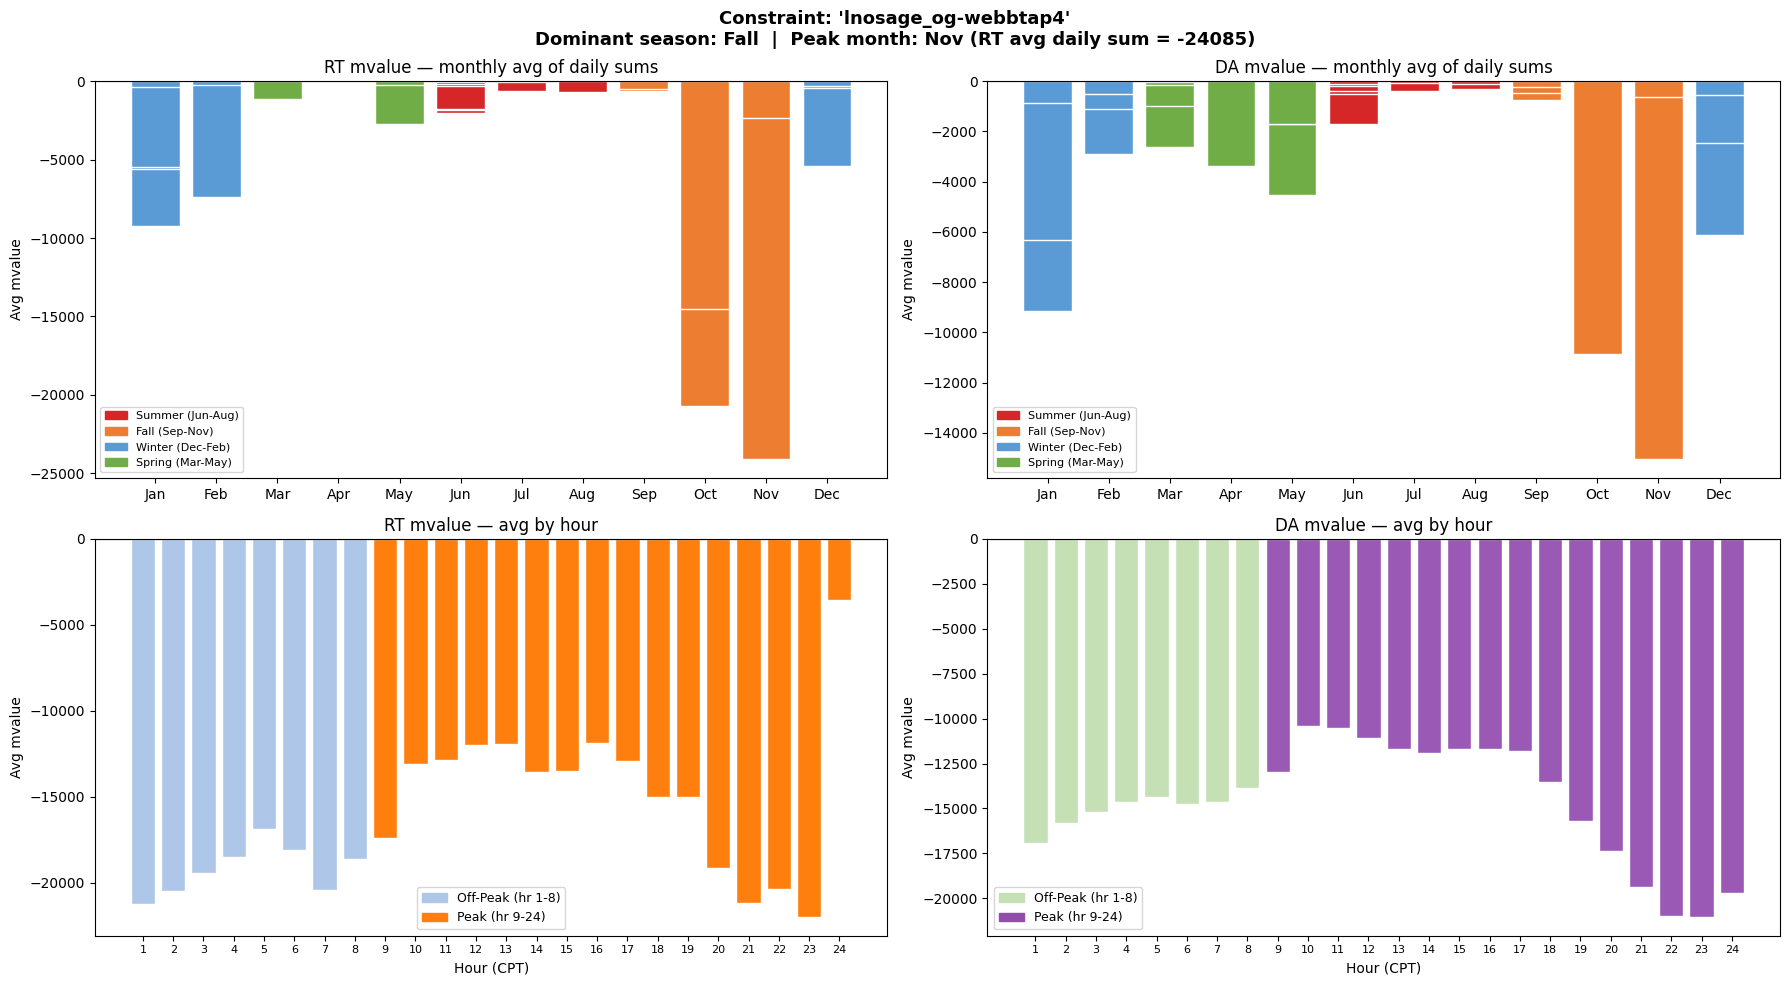

Dominant season : Fall
  Fall    :     318884  (sum abs RT daily mvalue)
  Winter  :      49494  (sum abs RT daily mvalue)
  Spring  :      10722  (sum abs RT daily mvalue)
  Summer  :       9712  (sum abs RT daily mvalue)

Peak month      : Nov  (daily RT sum = -24084.79)

RT  peak sum   (hr  9-24): -235240.26  |  off-peak (hr 1-8): -153570.56
DA  peak sum   (hr  9-24): -231497.02  |  off-peak (hr 1-8): -120236.10


In [36]:
show_result('lnosage_og-webbtap4', 4, 95)

In [35]:
mv_merged[mv_merged.monitored.str.contains('osage')].monitored.unique()

array(['lnwhegl-osage_og', 'lnosage_og-webbtap4'], dtype=object)

# Daily RT DA Spike Analysis 

In [ ]:
# give a date and returns to me the hourly metrics at that hour, wind/load/temperature/gas/wind ramp/genoutage

In [7]:
from nighthawk.data.pipeline.common_functions.wind import Wind
from nighthawk.data.pipeline.common_functions.load import Load
from nighthawk.data.pipeline.common_functions.gas import Gas
from nighthawk.data.pipeline.common_functions.genoutage import GenOutage
from nighthawk.data.pipeline.common_functions.weather import Weather
from nighthawk.data.network.node import Node

SPP_HUB_NODES = {636:'south_hub'}
SPP_CITIES =[ ('Kansas City', 'MO'), ('Oklahoma City', 'OK')]


def get_hourly_snapshot(date: str, hour: int):
    assert 1 <= hour <= 24, "hour must be between 1 and 24"
    dt      = date
    dt_prev = (pd.Timestamp(dt) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')

    wind_df = Wind('SPP').get_total_wind(dt_prev, dt, var_spec=['f'])
    load_df = Load('SPP').get_total_load(dt_prev, dt, var_spec=['f'])

    gas_raw = Gas('SPP').get_daily_gas_price(['Henry'], dt_prev, dt, pivot=False)
    gas_df  = (gas_raw[gas_raw['hub_name'] == 'Henry'][['dt', 'gas_price']]
               .rename(columns={'gas_price': 'henry_gas_price'}))

    go_raw = GenOutage('SPP').get_genoutage_by_level(dt_prev, dt, var_spec=['f'], area_list=['SPP'])
    go_df  = go_raw[go_raw['baa_zone'] == 'SPP'][['dt', 'hr', 'spp_genoutage_forecast_f']]

    weather_obj = Weather('SPP')
    city_ids    = weather_obj.get_city_details(SPP_CITIES)['CityId'].tolist()
    temp_raw    = weather_obj.get_citylevel_temperature_for_ve(dt_prev, dt, city_ids, pivot=False)
    temp_df     = (temp_raw.groupby(['dt', 'hr'])['temperature_degf']
                           .mean().reset_index()
                           .rename(columns={'temperature_degf': 'avg_temp_f'}))

    price_raw = Node(list(SPP_HUB_NODES.keys()), 'SPP').get_price(
        dt, dt, component=['Slack'], type=['DA', 'RT'], granularity='hourly'
    )
    price_raw['dt'] = price_raw['dt'].astype(str)
    price_raw['hr'] = price_raw['hr'].astype(int)

    for df in [wind_df, load_df, go_df, temp_df]:
        df['dt'] = df['dt'].astype(str)
        df['hr'] = df['hr'].astype(int)
    gas_df['dt'] = gas_df['dt'].astype(str)

    base = (
        wind_df[['dt', 'hr', 'spp_wind_total_forecast_f']]
        .merge(load_df[['dt', 'hr', 'spp_load_total_forecast_f']], on=['dt', 'hr'], how='outer')
        .merge(go_df,   on=['dt', 'hr'], how='left')
        .merge(temp_df, on=['dt', 'hr'], how='left')
        .merge(gas_df,  on='dt',         how='left')
        .sort_values(['dt', 'hr']).reset_index(drop=True)
    )
    base['B_wind_ramp'] = base['spp_wind_total_forecast_f'].diff()
    base['B_load_ramp'] = base['spp_load_total_forecast_f'].diff()
    base['B_wind_ramp_2'] = base['spp_wind_total_forecast_f'].diff(2)
    base['B_load_ramp_2'] = base['spp_load_total_forecast_f'].diff(2)

    row       = base[(base['dt'] == dt) & (base['hr'] == hour)]
    price_row = price_raw[(price_raw['dt'] == dt) & (price_raw['hr'] == hour)].copy()
    price_row['hub'] = price_row['node_num'].map(SPP_HUB_NODES)

    if row.empty:
        print(f"No data found for {dt} hour {hour}")
        return None

    r   = row.iloc[0]
    rec = {
        'dt':               dt,
        'hr':               hour,
        'wind_f (MW)':      round(r['spp_wind_total_forecast_f'], 1),
        'load_f (MW)':      round(r['spp_load_total_forecast_f'], 1),
        'genoutage_f (MW)': round(r['spp_genoutage_forecast_f'],  1),
        'avg_temp (°F)':    round(r['avg_temp_f'],                1),
        'henry_gas ($/MMBtu)': round(r['henry_gas_price'],        3),
        'wind_ramp (MW/hr)': round(r['B_wind_ramp'],                1),
        'load_ramp (MW/hr)': round(r['B_load_ramp'],                1),
        'wind_ramp_2 (MW/hr)': round(r['B_wind_ramp_2'],                1),
        'load_ramp_2 (MW/hr)': round(r['B_load_ramp_2'],                1),
    }

    for _, pr in price_row.sort_values('node_num').iterrows():
        hub = pr['hub']
        rec[f'{hub}_da_slack']  = round(pr.get('da_slack', float('nan')), 2)
        rec[f'{hub}_rt_slack']  = round(pr.get('rt_slack', float('nan')), 2)

    display(pd.DataFrame([rec]))
    return pd.DataFrame([rec])


# ── Example ───────────────────────────────────────────────
get_hourly_snapshot('2022-12-23', 18)


/tmp/ipykernel_3373402/756036728.py:28: DeprecationWarning: Call to deprecated function get_city_details.
  city_ids    = weather_obj.get_city_details(SPP_CITIES)['CityId'].tolist()


,dt,hr,wind_f (MW),load_f (MW),genoutage_f (MW),avg_temp (°F),henry_gas ($/MMBtu),wind_ramp (MW/hr),load_ramp (MW/hr),wind_ramp_2 (MW/hr),load_ramp_2 (MW/hr),south_hub_da_slack,south_hub_rt_slack
0,2022-12-23,18,10722.4,40623.0,11765.4,10.3,7.28,-930.1,1710.0,-2080.7,2397.0,149.7,1395.17


,dt,hr,wind_f (MW),load_f (MW),genoutage_f (MW),avg_temp (°F),henry_gas ($/MMBtu),wind_ramp (MW/hr),load_ramp (MW/hr),wind_ramp_2 (MW/hr),load_ramp_2 (MW/hr),south_hub_da_slack,south_hub_rt_slack
0,2022-12-23,18,10722.4,40623.0,11765.4,10.3,7.28,-930.1,1710.0,-2080.7,2397.0,149.7,1395.17


In [8]:
import sys
sys.path.append('/var/www/python/Prod/nighthawk/')
import pandas as pd
from nighthawk.util.bigquery_functions import download_df_from_bq

PNL_COLS = ['clear_mw', 'profit_total', 'profit_congestion', 'profit_slack']

def _fetch_pnl(start_dt: str, end_dt: str) -> pd.DataFrame:
    query = f"""
        SELECT dt, hr, incdec, strategy, rep_zone, broad_zone,
               SUM(clear_mw)          AS clear_mw,
               SUM(profit_total)      AS profit_total,
               SUM(profit_congestion) AS profit_congestion,
               SUM(profit_slack)      AS profit_slack
        FROM `movetocloud-999.virtual_financials.segment_portfolio_details_SPP`
        WHERE dt BETWEEN '{start_dt}' AND '{end_dt}'
        GROUP BY dt, hr, incdec, strategy, rep_zone, broad_zone
        ORDER BY dt, hr
    """
    df = download_df_from_bq(query)
    df['dt'] = pd.to_datetime(df['dt']).dt.strftime('%Y-%m-%d')
    df['hr'] = df['hr'].astype(int)
    return df


def get_spp_pnl(start_dt: str, end_dt: str, group_by: str = 'daily') -> pd.DataFrame:
    """
    Fetch SPP virtual portfolio PnL summed across all strategies.

    group_by: 'daily'  — one row per dt
              'hourly' — one row per dt x hr
              'raw'    — full detail (strategy / rep_zone / incdec)
    """
    assert group_by in ('daily', 'hourly', 'raw')
    df = _fetch_pnl(start_dt, end_dt)
    if group_by == 'daily':
        return df.groupby('dt', as_index=False)[PNL_COLS].sum()
    elif group_by == 'hourly':
        return df.groupby(['dt', 'hr'], as_index=False)[PNL_COLS].sum()
    return df


def get_pnl_snapshot(date: str, hour: int) -> pd.DataFrame:
    """Return a single-row DataFrame with total PnL for one specific date and hour."""
    df = _fetch_pnl(date, date)
    row = df[df['hr'] == hour][PNL_COLS].sum()
    result = pd.DataFrame([{'dt': date, 'hr': hour, **{c: round(row[c], 2) for c in PNL_COLS}}])
    display(result)
    return result


# Daily PnL (summed across all strategies, one row per dt)
daily = get_spp_pnl('2026-05-01', '2026-05-12', group_by='daily')
display(daily)

# Hourly PnL (one row per dt x hr)
hourly = get_spp_pnl('2026-05-01', '2026-05-12', group_by='hourly')
display(hourly)

# Single dt + hour snapshot
get_pnl_snapshot('2022-12-23', 18)


,dt,clear_mw,profit_total,profit_congestion,profit_slack
0,2026-05-01,1314.123994,10346.707933,-1462.969181,10884.276826
1,2026-05-02,1652.635993,-7083.557217,-12633.139192,21.284947
2,2026-05-03,3990.475993,7572.335125,-11842.373297,16723.520420
3,2026-05-04,2913.842014,-3192.139128,-4567.698330,114.950350
4,2026-05-05,4434.162016,16118.681327,8296.839209,4425.614313
5,2026-05-06,3987.468992,4770.107891,-11947.602979,10481.887688
6,2026-05-07,3755.137000,14547.367163,18762.518391,-9155.448334
7,2026-05-08,4304.602005,67370.198571,29204.468008,32124.305276
8,2026-05-09,3716.091997,11814.304184,-2532.667904,12250.674421
9,2026-05-10,4435.628995,-1795.961618,-2776.937795,-4689.680222


,dt,hr,clear_mw,profit_total,profit_congestion,profit_slack
0,2026-05-01,1,0.000000,0.000000,0.000000,0.000000
1,2026-05-01,2,159.647999,516.767106,1.068651,278.250245
2,2026-05-01,3,155.144999,466.455470,3.612927,239.142706
3,2026-05-01,4,192.359999,508.910930,14.164024,324.564199
4,2026-05-01,5,55.928000,88.684027,1.266369,90.660056
...,...,...,...,...,...,...
283,2026-05-12,20,303.584000,5554.949414,-1040.389066,6685.454566
284,2026-05-12,21,139.781999,528.337479,-962.382434,1357.113779
285,2026-05-12,22,178.310000,-1992.834609,-1714.769815,-434.276620
286,2026-05-12,23,148.264000,-683.636199,-587.452466,-254.631062


,dt,hr,clear_mw,profit_total,profit_congestion,profit_slack
0,2022-12-23,18,7.09,5328.41,493.17,4666.42


,dt,hr,clear_mw,profit_total,profit_congestion,profit_slack
0,2022-12-23,18,7.09,5328.41,493.17,4666.42


In [10]:
import os
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

SAVE_PATH   = '/mnt/disks/filedisk1/SPP/VE/spp_hourly_fundamentals.csv'
RF_FEATURES = [
    'wind_f (MW)', 'load_f (MW)', 'genoutage_f (MW)', 'avg_temp (°F)',
    'henry_gas ($/MMBtu)', 'wind_ramp (MW/hr)', 'load_ramp (MW/hr)',
    'wind_ramp_2 (MW/hr)', 'load_ramp_2 (MW/hr)',
]
TARGET = 'SHub_rt_slack'


def find_similar_hours(date: str, hour: int, k: int = 20,
                        dataset_path: str = SAVE_PATH,
                        n_estimators: int = 200) -> pd.DataFrame:
    """
    Train a RandomForest on (fundamentals -> SHub_rt_slack) using all history
    strictly before the given dt/hr, then rank historical hours by RF proximity
    (fraction of trees where a historical row shares the same leaf as the query).

    Returns top-k most similar rows sorted by rf_proximity descending,
    with the query row prepended (rf_proximity = 1.0).
    """
    df = pd.read_csv(dataset_path)
    df['dt'] = df['dt'].astype(str)
    df['hr'] = df['hr'].astype(int)

    # --- strict past-only filter ---
    cutoff    = pd.Timestamp(date) + pd.Timedelta(hours=hour - 1)
    df['_ts'] = pd.to_datetime(df['dt']) + pd.to_timedelta(df['hr'] - 1, unit='h')
    hist      = df[df['_ts'] < cutoff].drop(columns='_ts').reset_index(drop=True)

    # --- query row ---
    query_rows = df[(df['dt'] == date) & (df['hr'] == hour)].drop(columns='_ts', errors='ignore')
    if query_rows.empty:
        print('Query dt/hr not in dataset, fetching live...')
        query_row = get_hourly_snapshot(date, hour)
    else:
        query_row = query_rows.iloc[[0]]

    # --- feature matrix ---
    feat_cols = [c for c in RF_FEATURES if c in hist.columns and c in query_row.columns]
    train_mask = hist[feat_cols].notna().all(axis=1) & hist[TARGET].notna()
    hist_clean = hist[train_mask].reset_index(drop=True)

    X_train = hist_clean[feat_cols].values
    y_train = hist_clean[TARGET].values
    X_query = query_row[feat_cols].fillna(0).values

    # --- train RF ---
    rf = RandomForestRegressor(n_estimators=n_estimators, random_state=42,
                               n_jobs=-1, max_features='sqrt')
    rf.fit(X_train, y_train)

    print(f'RF trained on {len(X_train)} rows | '
          f'top features: {sorted(zip(rf.feature_importances_, feat_cols), reverse=True)[:3]}')

    # --- RF proximity: fraction of trees sharing the same leaf ---
    # apply() returns shape (n_samples, n_estimators) — leaf index per tree
    hist_leaves  = rf.apply(X_train)          # (n_hist, n_trees)
    query_leaves = rf.apply(X_query)          # (1,      n_trees)
    proximity    = (hist_leaves == query_leaves).mean(axis=1)  # (n_hist,)

    # --- top k by proximity ---
    k = min(k, len(hist_clean))
    top_idx  = np.argsort(proximity)[::-1][:k]
    neighbours = hist_clean.iloc[top_idx].copy()
    neighbours.insert(0, 'rf_proximity', proximity[top_idx].round(4))
    neighbours = neighbours.sort_values('rf_proximity', ascending=False).reset_index(drop=True)

    # --- remove any row from the query date before prepending query row ---
    neighbours = neighbours[neighbours['dt'] != date].sort_values('rf_proximity',ascending=False)
    # neighbours = neighbours.sort_values('SHub_rt_slack', ascending=False).groupby('dt').head(3).sort_values('SHub_rt_slack', ascending=False)
    # --- prepend query row ---
    q = query_row.copy()
    q.insert(0, 'rf_proximity', 1.0)
    result = pd.concat([q, neighbours], ignore_index=True)
    return result


# ── Example ───────────────────────────────────────────────
find_similar_hours('2026-02-05', 17, k=20)


RF trained on 53458 rows | top features: [(np.float64(0.2462259813613005), 'avg_temp (°F)'), (np.float64(0.15052681429048678), 'genoutage_f (MW)'), (np.float64(0.1383914165600613), 'henry_gas ($/MMBtu)')]


,rf_proximity,dt,hr,wind_f (MW),load_f (MW),genoutage_f (MW),avg_temp (°F),henry_gas ($/MMBtu),wind_ramp (MW/hr),load_ramp (MW/hr),wind_ramp_2 (MW/hr),load_ramp_2 (MW/hr),SHub_da_slack,SHub_rt_slack,clear_mw,profit_total,profit_congestion,profit_slack
0,1.000,2026-02-05,17,14289.63,32834.0,10650.1,59.500000,6.43,-1461.28,295.0,-2410.89,11.0,28.1054,404.1851,206.440001,-62365.938848,387.063636,-65353.675389
1,0.170,2022-07-01,6,14438.65,30901.0,8863.1,73.166667,6.46,-1117.83,138.0,-2486.89,-172.0,30.8206,45.4116,23.939000,-40.729554,74.293929,-263.847374
2,0.075,2022-08-16,6,13548.89,32258.0,6419.1,74.166667,8.55,-1221.32,342.0,-2240.43,31.0,40.2045,55.4238,103.304000,957.512408,908.283454,-579.449514
3,0.045,2022-07-25,6,14579.86,33429.0,7723.6,75.833333,8.24,-1078.63,420.0,-2080.29,51.0,36.4565,49.6445,61.907000,-192.575932,-491.847419,-21.042240
4,0.045,2022-04-13,19,14265.99,29406.0,21813.5,52.333333,6.56,-1165.66,-29.0,-2153.31,-81.0,50.7048,44.5023,109.996001,1498.184027,1851.563093,-600.867565
5,0.045,2022-09-29,10,14386.65,28338.0,16650.0,59.000000,6.60,-1142.15,482.0,-1888.43,831.0,40.2965,62.2358,156.316001,244.029452,3065.127021,-3467.083809
6,0.040,2022-04-25,12,14301.43,28245.0,24450.6,52.333333,6.55,-1507.18,-42.0,-2526.24,126.0,41.8679,24.2558,117.336000,5086.091929,5225.552505,-458.295572
7,0.040,2022-12-19,12,13647.13,34908.0,14665.5,40.500000,6.59,-1428.13,-398.0,-3147.18,-656.0,62.9655,55.5540,54.907000,259.616920,177.717612,-65.472462
8,0.040,2022-06-18,8,13801.18,30728.0,9573.1,75.500000,7.34,-1470.64,1218.0,-2445.80,1102.0,39.2255,47.2523,39.387000,893.380030,880.272826,-203.056099
9,0.035,2022-07-01,5,15556.48,30763.0,8863.1,73.500000,6.46,-1369.06,-310.0,-2613.74,-958.0,23.0436,47.1452,22.901000,-197.759024,-1.283994,-348.660561


In [44]:
dt_hr_list = [
    ('2022-12-23', 18),('2026-01-17', 3), ('2026-02-04', 18),
    ('2021-11-11', 18),  ('2025-03-30', 21),
    ('2022-05-16', 18), ('2025-06-29', 15), ('2025-09-24', 19), ('2025-05-20', 20),
]

all_results = {}
for dt, hr in dt_hr_list:
    print(f'\n=== {dt} hr {hr} ===')
    all_results[(dt, hr)] = find_similar_hours(dt, hr, k=20)
    display(all_results[(dt,hr)][:5])



=== 2022-12-23 hr 18 ===
RF trained on 26102 rows | top features: [(np.float64(0.3517267665393743), 'avg_temp (°F)'), (np.float64(0.14787076529765056), 'genoutage_f (MW)'), (np.float64(0.11915737937016378), 'load_f (MW)')]


,rf_proximity,dt,hr,wind_f (MW),load_f (MW),genoutage_f (MW),avg_temp (°F),henry_gas ($/MMBtu),wind_ramp (MW/hr),load_ramp (MW/hr),wind_ramp_2 (MW/hr),load_ramp_2 (MW/hr),SHub_da_slack,SHub_rt_slack,clear_mw,profit_total,profit_congestion,profit_slack
0,1.000,2022-12-23,18,10722.36,40623.0,11765.4,10.333333,7.28,-930.11,1710.0,-2080.71,2397.0,149.7030,1395.1707,7.093000,5328.412735,493.169254,4666.423157
1,0.060,2022-02-03,8,18479.10,39761.0,9933.6,9.833333,6.44,-536.04,1688.0,-843.36,3957.0,67.6235,16.4852,27.882000,576.161217,470.239969,84.786464
2,0.040,2021-02-12,8,5126.41,40966.0,16781.4,9.333333,5.89,-301.01,1541.0,-574.68,3823.0,176.6228,48.4796,0.335000,-7.802134,35.629878,-43.069902
3,0.035,2022-02-04,9,11482.97,41554.0,8605.2,10.333333,5.88,-244.91,-296.0,-145.94,1370.0,66.6409,29.1555,154.803001,-2626.705592,2868.539553,-5779.484066
4,0.035,2022-02-04,8,11727.88,41850.0,8605.2,9.666667,5.88,98.97,1666.0,118.33,3931.0,65.8899,29.8565,204.547002,-4188.044646,2809.327337,-7368.555217



=== 2026-01-17 hr 3 ===
RF trained on 52988 rows | top features: [(np.float64(0.2673813377561214), 'avg_temp (°F)'), (np.float64(0.15487312825880692), 'henry_gas ($/MMBtu)'), (np.float64(0.1334310772699842), 'genoutage_f (MW)')]


,rf_proximity,dt,hr,wind_f (MW),load_f (MW),genoutage_f (MW),avg_temp (°F),henry_gas ($/MMBtu),wind_ramp (MW/hr),load_ramp (MW/hr),wind_ramp_2 (MW/hr),load_ramp_2 (MW/hr),SHub_da_slack,SHub_rt_slack,clear_mw,profit_total,profit_congestion,profit_slack
0,1.000,2026-01-17,3,24073.37,33932.0,10055.5,28.0,3.13,-889.21,142.0,-1389.39,52.0,4.8618,417.6024,230.266000,30096.487343,-1469.454012,32915.618710
1,0.145,2026-01-16,21,23834.31,36154.0,10114.1,33.5,2.94,-405.74,65.0,-1219.75,167.0,18.4558,26.2267,99.055001,1321.798281,1491.678464,-460.555193
2,0.065,2025-12-28,21,22812.73,35261.0,10238.8,28.0,3.29,-1403.37,-119.0,-3205.40,54.0,22.6337,26.7415,128.843000,-631.711309,-981.362203,296.493661
3,0.040,2026-01-16,17,26845.08,34154.0,9986.6,45.0,2.94,-425.82,359.0,-754.40,287.0,9.9081,18.7125,183.167000,-4131.239875,-4585.885151,151.045029
4,0.040,2026-01-16,22,23796.11,35913.0,10115.1,32.5,2.94,-38.20,-241.0,-443.94,-176.0,14.5170,9.5475,81.564000,1260.204945,1067.932902,41.510146



=== 2026-02-04 hr 18 ===
RF trained on 53435 rows | top features: [(np.float64(0.2489874287911368), 'avg_temp (°F)'), (np.float64(0.15274886014376093), 'genoutage_f (MW)'), (np.float64(0.1410593652581928), 'henry_gas ($/MMBtu)')]


...

,rf_proximity,dt,hr,wind_f (MW),load_f (MW),genoutage_f (MW),avg_temp (°F),henry_gas ($/MMBtu),wind_ramp (MW/hr),load_ramp (MW/hr),wind_ramp_2 (MW/hr),load_ramp_2 (MW/hr),SHub_da_slack,SHub_rt_slack,clear_mw,profit_total,profit_congestion,profit_slack
0,1.000,2025-06-29,15,11390.88,44661.0,8701.5,90.000000,3.22,373.01,1068.0,461.79,2504.0,46.0446,622.4724,93.540000,-41896.412740,-6865.781361,-36946.866311
1,0.100,2021-07-09,15,11291.67,44662.0,6927.0,88.333333,3.54,446.74,1233.0,823.20,2902.0,45.1745,45.0627,159.343001,1332.818885,1037.165550,-222.152825
2,0.075,2021-06-25,15,9923.23,45208.0,9423.6,88.500000,3.30,536.96,887.0,685.74,2254.0,50.6905,57.1629,96.513000,-671.083731,-356.207669,-526.841020
3,0.055,2025-06-28,15,15815.28,44222.0,9496.4,90.000000,3.22,559.21,1128.0,967.35,2619.0,41.9330,25.7528,168.147998,-2716.454690,-512.423559,-2270.645614
4,0.050,2021-08-28,15,12946.33,44075.0,9290.9,89.000000,4.34,260.21,1165.0,345.68,2823.0,54.5669,73.5082,186.873001,5811.562915,4308.236912,1399.791731



=== 2025-09-24 hr 19 ===
RF trained on 50244 rows | top features: [(np.float64(0.26715422524801047), 'avg_temp (°F)'), (np.float64(0.15802112912832297), 'henry_gas ($/MMBtu)'), (np.float64(0.14684756859382092), 'genoutage_f (MW)')]


,rf_proximity,dt,hr,wind_f (MW),load_f (MW),genoutage_f (MW),avg_temp (°F),henry_gas ($/MMBtu),wind_ramp (MW/hr),load_ramp (MW/hr),wind_ramp_2 (MW/hr),load_ramp_2 (MW/hr),SHub_da_slack,SHub_rt_slack,clear_mw,profit_total,profit_congestion,profit_slack
0,1.000,2025-09-24,19,11478.25,36273.0,14440.1,75.000000,2.87,-1460.28,-583.0,-1989.78,-769.0,49.7183,617.0778,268.148999,-103264.498268,-14502.716887,-89335.393847
1,0.085,2024-01-18,2,13168.42,36429.0,14095.7,26.833333,2.87,-1033.68,-300.0,-2048.19,-738.0,43.6217,45.3173,68.432000,-180.583930,-294.822214,48.442778
2,0.060,2024-09-28,19,11351.65,36058.0,18921.9,82.000000,2.53,-1486.38,-889.0,-2059.69,-880.0,42.5656,58.8449,309.817000,3507.943992,6816.360136,-3846.278321
3,0.045,2024-05-24,19,8394.14,36043.0,19932.2,78.000000,2.61,-956.99,-617.0,-2124.81,-1084.0,47.9297,30.5565,124.491001,3008.421503,1637.696603,1075.928690
4,0.040,2024-01-18,3,12420.92,36279.0,14095.7,26.166667,2.87,-747.50,-150.0,-1781.18,-450.0,43.0894,42.7880,87.973000,806.968520,843.941696,-109.396189



=== 2025-05-20 hr 20 ===
RF trained on 47197 rows | top features: [(np.float64(0.2641685441211271), 'avg_temp (°F)'), (np.float64(0.15230979499107578), 'henry_gas ($/MMBtu)'), (np.float64(0.14788250685991955), 'genoutage_f (MW)')]


,rf_proximity,dt,hr,wind_f (MW),load_f (MW),genoutage_f (MW),avg_temp (°F),henry_gas ($/MMBtu),wind_ramp (MW/hr),load_ramp (MW/hr),wind_ramp_2 (MW/hr),load_ramp_2 (MW/hr),SHub_da_slack,SHub_rt_slack,clear_mw,profit_total,profit_congestion,profit_slack
0,1.000,2025-05-20,20,13389.14,33568.0,21927.6,73.0,3.01,-3130.23,-637.0,-5366.93,-931.0,59.4740,531.0086,95.915000,-14299.096186,124.527912,-14503.588015
1,0.155,2024-12-04,11,13440.69,33261.0,22187.2,47.0,2.88,-2722.45,-520.0,-5476.41,-1049.0,36.0682,24.1867,202.483999,-1138.068365,922.769615,-2420.047924
2,0.085,2024-05-13,20,13485.62,31822.0,25337.9,70.5,2.15,-2321.36,-661.0,-3489.35,-959.0,42.2020,148.1874,114.758000,-8051.868541,826.875282,-9252.273618
3,0.060,2024-12-19,11,16171.69,34722.0,16699.4,42.5,3.02,-3166.56,-803.0,-5314.98,-1651.0,35.0636,25.6772,38.394000,201.147720,569.172909,-363.752633
4,0.060,2024-05-13,21,11288.06,31287.0,25337.9,68.0,2.15,-2197.56,-535.0,-4518.92,-1196.0,48.4514,259.7657,35.884000,3260.100060,1834.467407,1392.752010
